# R5/R6 - Análisis de Resultados Formales de Clasificación

Este notebook cubre dos etapas de la investigación, usando las mismas 9 corridas formales:

**R5 - Comparación controlada** (secciones 1-5): evidencia de entrenamiento y comportamiento
de las 9 corridas (3 arquitecturas × 3 condiciones A/B/C) bajo protocolo común.

**R6 - Selección de arquitectura** (secciones 6-9): comparación de arquitecturas exclusivamente
en condición B (pipeline automatizado U-Net -> CNN), selección final y motivación para el sigueinte resultado.

---
**Arquitecturas:** ResNet50, DenseNet121, ConvNeXt-Tiny

**Condiciones:** A (imagen completa), B (ROI predicha por U-Net), C (ROI ground truth)

**Protocolo:** AdamW lr=1e-4, wd=1e-4, WCE, patience=5, seed=42, AMP, sin scheduler

**Métrica principal de selección:** Average Precision (AP)

**Condición de selección:** B (pipeline automatizado)

---



# PARTE I - R5: Comparación controlada
---

## 1. Carga de resultados

In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
pd.set_option("display.float_format", "{:.4f}".format)

FORMAL_DIR = Path("../../results/classification/formal")
ARCHS = ["resnet50", "densenet121", "convnext_tiny"]
CONDITIONS = ["A", "B", "C"]
ARCH_LABELS = {"resnet50": "ResNet50", "densenet121": "DenseNet121", "convnext_tiny": "ConvNeXt-Tiny"}
COND_LABELS = {"A": "A (Full)", "B": "B (ROI Pred)", "C": "C (ROI GT)"}

In [2]:
records = []
histories = {}
configs = {}

for arch in ARCHS:
    for cond in CONDITIONS:
        run_dir = FORMAL_DIR / arch / cond
        label = f"{ARCH_LABELS[arch]} — {cond}"

        with open(run_dir / "validation_metrics.json") as f:
            vm = json.load(f)
        with open(run_dir / "run_config.json") as f:
            rc = json.load(f)
        with open(run_dir / "training_history.json") as f:
            hist = json.load(f)

        records.append({
            "Arquitectura": ARCH_LABELS[arch],
            "arch_key": arch,
            "Condición": cond,
            "Accuracy": vm["accuracy"],
            "Balanced Acc": vm["balanced_accuracy"],
            "Precision M": vm["precision_malignant"],
            "Recall M": vm["recall_malignant"],
            "Specificity": vm["specificity"],
            "F1 M": vm["f1_malignant"],
            "ROC-AUC": vm["roc_auc"],
            "AP": vm["average_precision"],
            "CM": vm["confusion_matrix"],
            "Epoch Best": rc["epoch_best"],
            "Epochs Run": rc["epochs_run"],
            "Early Stopped": rc["early_stopped"],
        })
        histories[(arch, cond)] = hist
        configs[(arch, cond)] = rc

df = pd.DataFrame(records)
print(f"Corridas cargadas: {len(df)}/9")
print(f"Class weights (compartidos): {configs[('resnet50','A')]['class_weights']}")

Corridas cargadas: 9/9
Class weights (compartidos): [0.5610098242759705, 4.597701072692871]


## 2. Tabla consolidada de métricas (9 corridas)

In [3]:
display_cols = ["Arquitectura", "Condición", "Accuracy", "Balanced Acc",
                "Precision M", "Recall M", "Specificity", "F1 M",
                "ROC-AUC", "AP", "Epoch Best", "Epochs Run", "Early Stopped"]

df_display = df[display_cols].copy()
df_display

,Arquitectura,Condición,Accuracy,Balanced Acc,Precision M,Recall M,Specificity,F1 M,ROC-AUC,AP,Epoch Best,Epochs Run,Early Stopped
0,ResNet50,A,0.8300,0.5061,0.1250,0.0909,0.9213,0.1053,0.7188,0.2401,2,7,True
1,ResNet50,B,0.6750,0.5585,0.1475,0.4091,0.7079,0.2169,0.5804,0.1728,1,6,True
2,ResNet50,C,0.8100,0.6343,0.2647,0.4091,0.8596,0.3214,0.6402,0.3045,1,6,True
3,DenseNet121,A,0.8650,0.7250,0.4138,0.5455,0.9045,0.4706,0.8483,0.5177,3,8,True
4,DenseNet121,B,0.6600,0.6098,0.1714,0.5455,0.6742,0.2609,0.6570,0.2546,2,7,True
5,DenseNet121,C,0.8500,0.7165,0.3750,0.5455,0.8876,0.4444,0.7837,0.3801,2,7,True
6,ConvNeXt-Tiny,A,0.7750,0.7740,0.2982,0.7727,0.7753,0.4304,0.8853,0.5898,8,13,True
7,ConvNeXt-Tiny,B,0.6650,0.6126,0.1739,0.5455,0.6798,0.2637,0.6997,0.3691,4,9,True
8,ConvNeXt-Tiny,C,0.4250,0.5575,0.1280,0.7273,0.3876,0.2177,0.6210,0.2359,1,6,True


## 3. Curvas de entrenamiento (loss y accuracy por época)

Comportamiento de las 9 corridas durante el entrenamiento.
La línea verde marca la época del mejor checkpoint (mínimo val_weighted_loss).

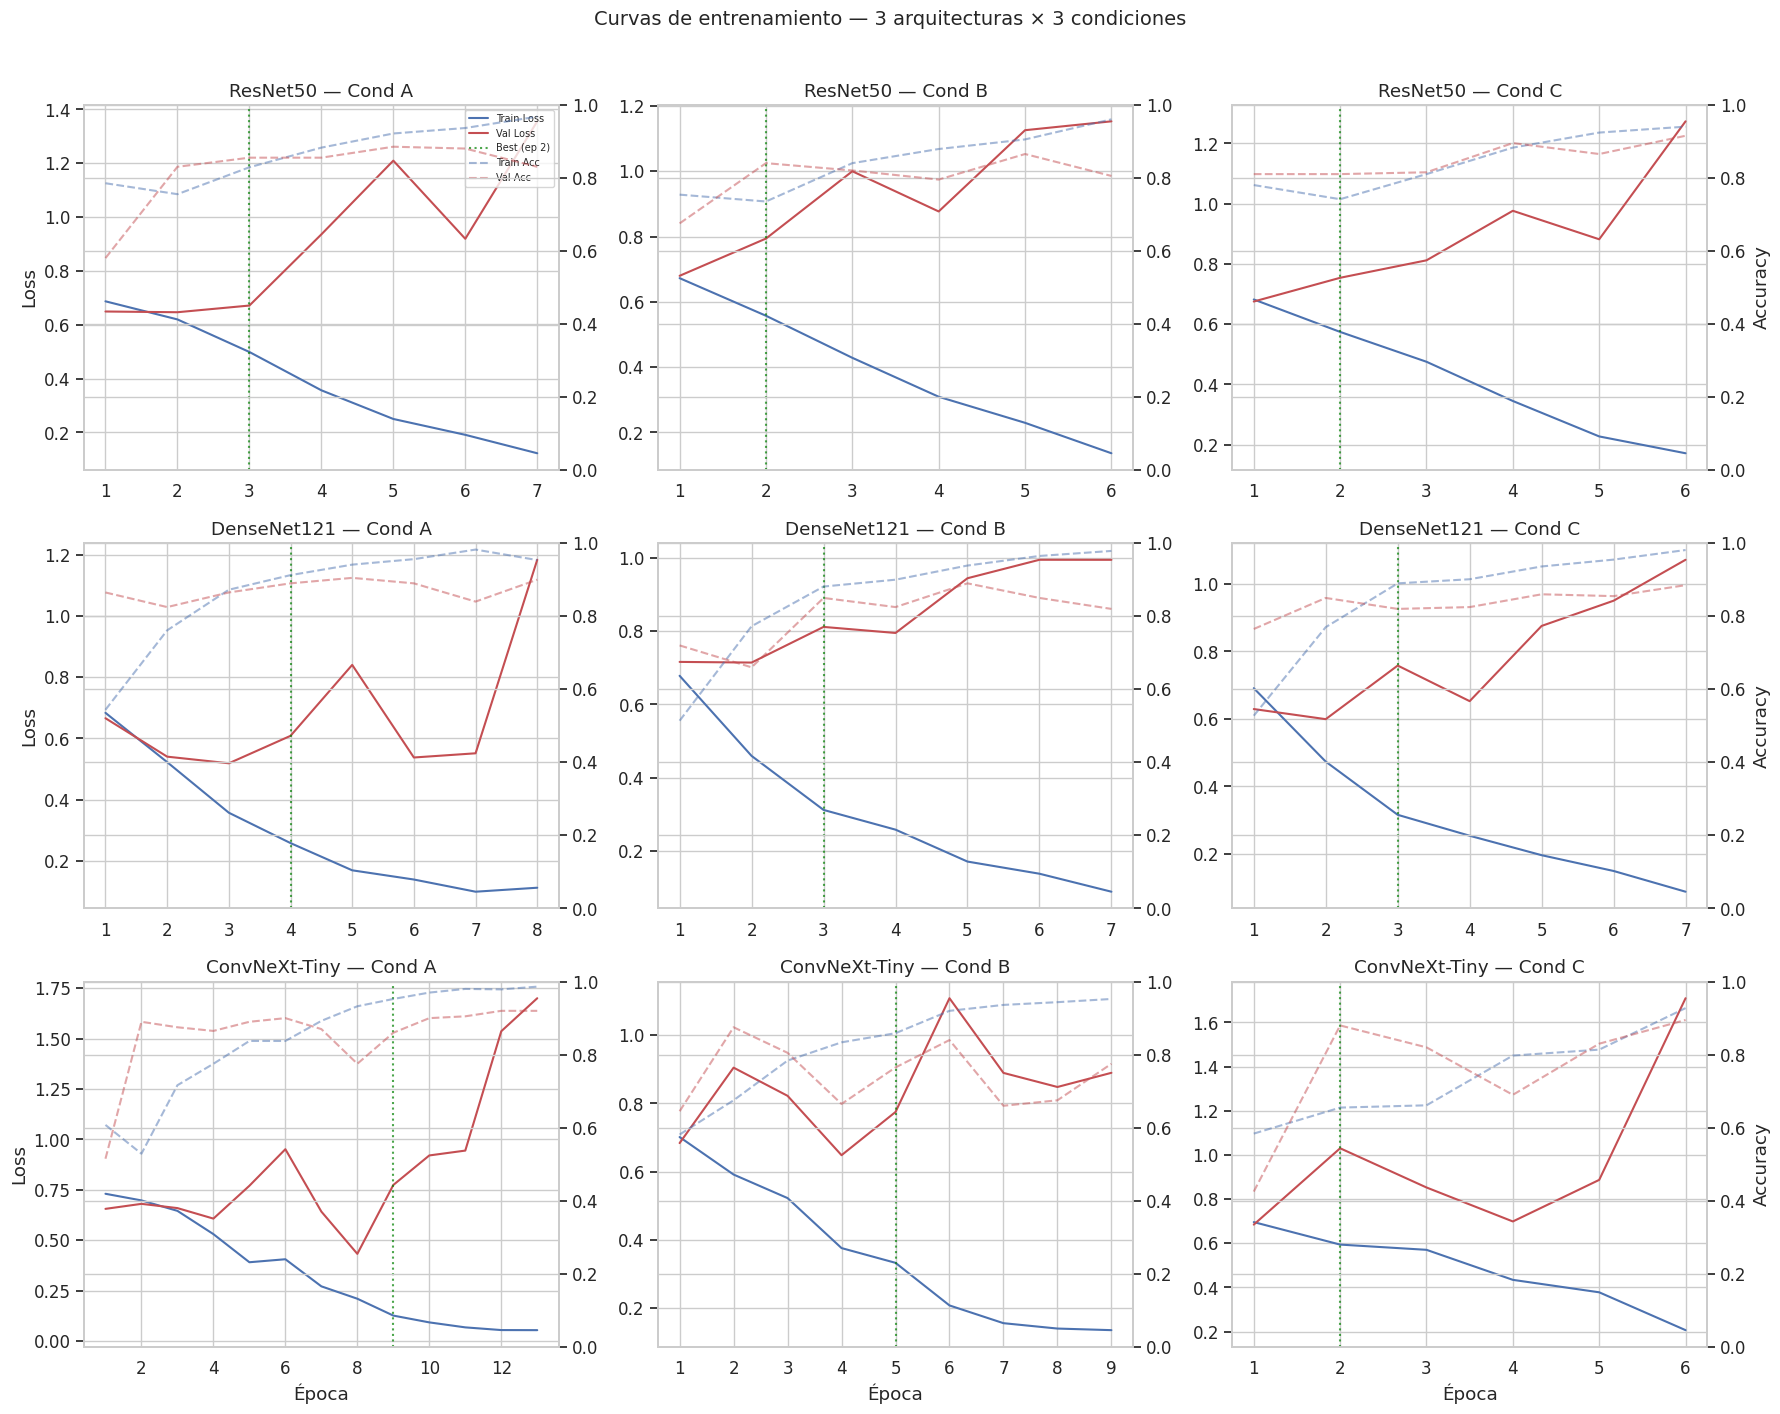

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for i, arch in enumerate(ARCHS):
    for j, cond in enumerate(CONDITIONS):
        ax = axes[i, j]
        hist = histories[(arch, cond)]
        epochs = range(1, len(hist["train_loss"]) + 1)

        ax.plot(epochs, hist["train_loss"], "b-", label="Train Loss", linewidth=1.5)
        ax.plot(epochs, hist["val_loss"], "r-", label="Val Loss", linewidth=1.5)

        ax2 = ax.twinx()
        ax2.plot(epochs, hist["train_acc"], "b--", alpha=0.5, label="Train Acc")
        ax2.plot(epochs, hist["val_acc"], "r--", alpha=0.5, label="Val Acc")
        ax2.set_ylim(0, 1)

        rc = configs[(arch, cond)]
        ax.axvline(x=rc["epoch_best"] + 1, color="green", linestyle=":", alpha=0.7, label=f"Best (ep {rc['epoch_best']})")

        ax.set_title(f"{ARCH_LABELS[arch]} — Cond {cond}")
        if j == 0:
            ax.set_ylabel("Loss")
        if j == 2:
            ax2.set_ylabel("Accuracy")
        if i == 2:
            ax.set_xlabel("Época")

        if i == 0 and j == 0:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper right")

fig.suptitle("Curvas de entrenamiento — 3 arquitecturas × 3 condiciones", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Evidencia de sobreajuste

Brechas train-val en loss y accuracy al momento del mejor checkpoint y al final del entrenamiento.

In [5]:
overfit_records = []

for arch in ARCHS:
    for cond in CONDITIONS:
        hist = histories[(arch, cond)]
        rc = configs[(arch, cond)]
        best_ep = rc["epoch_best"]       # 1-based: número de época para mostrar
        best_idx = best_ep - 1           # 0-based: índice en los arrays de history
        last_ep = len(hist["train_loss"]) - 1

        overfit_records.append({
            "Arquitectura": ARCH_LABELS[arch],
            "Cond": cond,
            "Best Epoch": best_ep,
            "Epochs Run": rc["epochs_run"],
            "Train Loss (best)": hist["train_loss"][best_idx],
            "Val Loss (best)": hist["val_loss"][best_idx],
            "Gap Loss (best)": hist["val_loss"][best_idx] - hist["train_loss"][best_idx],
            "Train Acc (best)": hist["train_acc"][best_idx],
            "Val Acc (best)": hist["val_acc"][best_idx],
            "Gap Acc (best)": hist["train_acc"][best_idx] - hist["val_acc"][best_idx],
            "Train Loss (last)": hist["train_loss"][last_ep],
            "Val Loss (last)": hist["val_loss"][last_ep],
            "Gap Loss (last)": hist["val_loss"][last_ep] - hist["train_loss"][last_ep],
            "Train Acc (last)": hist["train_acc"][last_ep],
            "Val Acc (last)": hist["val_acc"][last_ep],
            "Gap Acc (last)": hist["train_acc"][last_ep] - hist["val_acc"][last_ep],
        })

df_overfit = pd.DataFrame(overfit_records)

print("Brechas train-val al mejor checkpoint y al final del entrenamiento:")
display(df_overfit[["Arquitectura", "Cond", "Best Epoch", "Epochs Run",
                     "Gap Loss (best)", "Gap Acc (best)",
                     "Gap Loss (last)", "Gap Acc (last)"]].round(4))

print("\nNota: Gap Loss = val_loss − train_loss (positivo = val peor que train)")
print("      Gap Acc  = train_acc − val_acc  (positivo = train mejor que val)")
print("\nObservación: todas las corridas terminaron por early stopping antes de")
print("la época 30. Los mejores checkpoints se concentran en épocas muy tempranas,")
print("lo que sugiere sobreajuste rápido → motivación para R7.")

Brechas train-val al mejor checkpoint y al final del entrenamiento:


,Arquitectura,Cond,Best Epoch,Epochs Run,Gap Loss (best),Gap Acc (best),Gap Loss (last),Gap Acc (last)
0,ResNet50,A,2,7,0.0267,-0.0750,1.2328,0.1375
1,ResNet50,B,1,6,0.0072,0.0787,1.0164,0.1550
2,ResNet50,C,1,6,-0.0069,-0.0300,1.1013,0.0250
3,DenseNet121,A,3,8,0.1617,0.0075,1.0725,0.0537
4,DenseNet121,B,2,7,0.2546,0.1125,0.9052,0.1588
5,DenseNet121,C,2,7,0.1257,-0.0800,0.9829,0.0962
6,ConvNeXt-Tiny,A,8,13,0.2226,0.1575,1.6464,0.0662
7,ConvNeXt-Tiny,B,4,9,0.2721,0.1687,0.7538,0.1775
8,ConvNeXt-Tiny,C,1,6,-0.0114,0.1588,1.5024,0.0325



Nota: Gap Loss = val_loss − train_loss (positivo = val peor que train)
      Gap Acc  = train_acc − val_acc  (positivo = train mejor que val)

Observación: todas las corridas terminaron por early stopping antes de
la época 30. Los mejores checkpoints se concentran en épocas muy tempranas,
lo que sugiere sobreajuste rápido → motivación para R7.


## 5. Análisis complementario: comparación A vs B vs C por arquitectura

Este análisis examina las diferencias de desempeño según la condición de entrada, dentro de cada arquitectura:
- **A vs B** = diferencia al usar ROI automática frente a imagen completa
- **B vs C** = diferencia al sustituir la ROI predicha por una ROI basada en ground truth
- **A vs C** = diferencia entre imagen completa y ROI basada en ground truth

La condición C es una condición de referencia (oráculo): usa ROIs derivadas de la segmentación manual,
lo que no es reproducible en el pipeline automático. Su función es establecer un punto de comparación,
no un techo alcanzable.

In [6]:
key_metrics = ["AP", "Recall M", "Balanced Acc", "ROC-AUC", "F1 M", "Specificity"]

for arch in ARCHS:
    arch_label = ARCH_LABELS[arch]
    df_arch = df[df["arch_key"] == arch].set_index("Condición")
    print(f"\n{'='*60}")
    print(f"{arch_label}")
    print(f"{'='*60}")
    display(df_arch[key_metrics])

    delta_BA = df_arch.loc["B", "AP"] - df_arch.loc["A", "AP"]
    delta_CA = df_arch.loc["C", "AP"] - df_arch.loc["A", "AP"]
    delta_CB = df_arch.loc["C", "AP"] - df_arch.loc["B", "AP"]
    print(f"  Δ AP (B−A): {delta_BA:+.4f}  ← diferencia con ROI automática vs imagen completa")
    print(f"  Δ AP (C−A): {delta_CA:+.4f}  ← diferencia con ROI GT vs imagen completa")
    print(f"  Δ AP (C−B): {delta_CB:+.4f}  ← diferencia entre ROI GT y ROI predicha")


ResNet50


,AP,Recall M,Balanced Acc,ROC-AUC,F1 M,Specificity
Condición,,,,,,
A,0.2401,0.0909,0.5061,0.7188,0.1053,0.9213
B,0.1728,0.4091,0.5585,0.5804,0.2169,0.7079
C,0.3045,0.4091,0.6343,0.6402,0.3214,0.8596


  Δ AP (B−A): -0.0673  ← diferencia con ROI automática vs imagen completa
  Δ AP (C−A): +0.0644  ← diferencia con ROI GT vs imagen completa
  Δ AP (C−B): +0.1317  ← diferencia entre ROI GT y ROI predicha

DenseNet121


,AP,Recall M,Balanced Acc,ROC-AUC,F1 M,Specificity
Condición,,,,,,
A,0.5177,0.5455,0.7250,0.8483,0.4706,0.9045
B,0.2546,0.5455,0.6098,0.6570,0.2609,0.6742
C,0.3801,0.5455,0.7165,0.7837,0.4444,0.8876


  Δ AP (B−A): -0.2631  ← diferencia con ROI automática vs imagen completa
  Δ AP (C−A): -0.1376  ← diferencia con ROI GT vs imagen completa
  Δ AP (C−B): +0.1255  ← diferencia entre ROI GT y ROI predicha

ConvNeXt-Tiny


,AP,Recall M,Balanced Acc,ROC-AUC,F1 M,Specificity
Condición,,,,,,
A,0.5898,0.7727,0.7740,0.8853,0.4304,0.7753
B,0.3691,0.5455,0.6126,0.6997,0.2637,0.6798
C,0.2359,0.7273,0.5575,0.6210,0.2177,0.3876


  Δ AP (B−A): -0.2207  ← diferencia con ROI automática vs imagen completa
  Δ AP (C−A): -0.3538  ← diferencia con ROI GT vs imagen completa
  Δ AP (C−B): -0.1331  ← diferencia entre ROI GT y ROI predicha


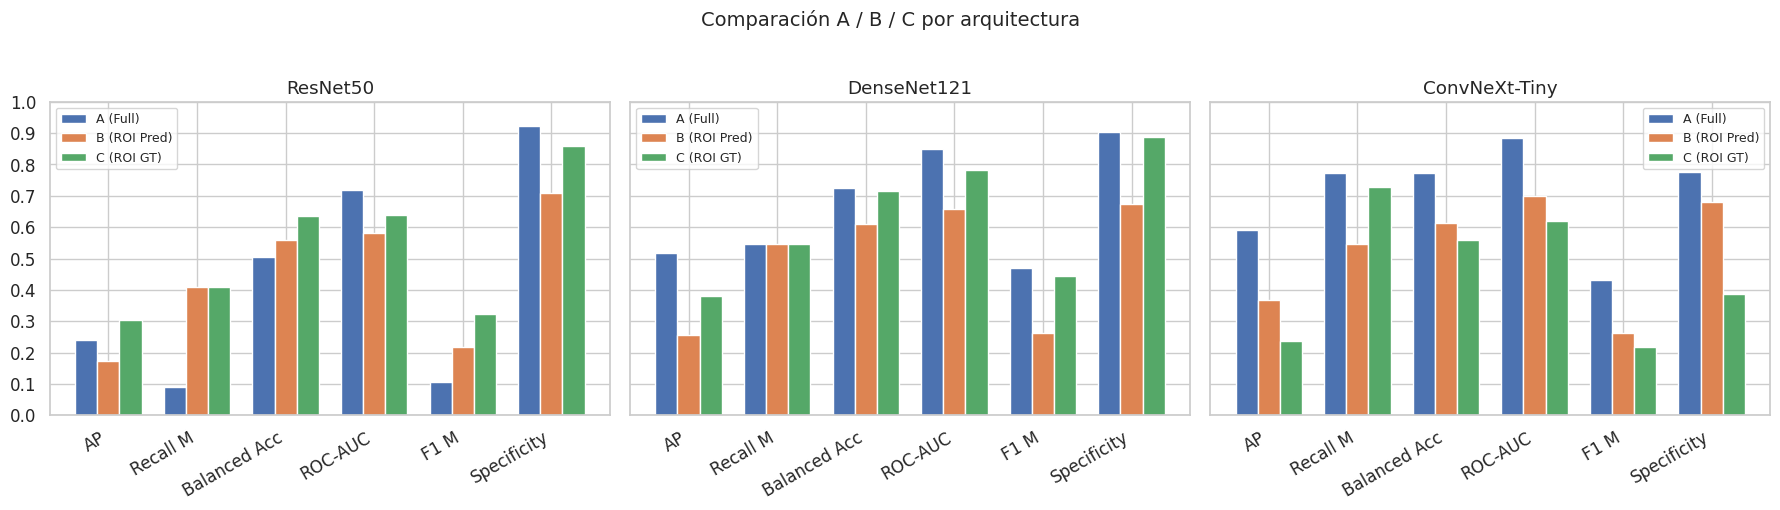

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, arch in enumerate(ARCHS):
    ax = axes[idx]
    df_arch = df[df["arch_key"] == arch]
    x = np.arange(len(key_metrics))
    width = 0.25

    for j, cond in enumerate(CONDITIONS):
        row = df_arch[df_arch["Condición"] == cond].iloc[0]
        vals = [row[m] for m in key_metrics]
        ax.bar(x + j * width, vals, width, label=COND_LABELS[cond])

    ax.set_xticks(x + width)
    ax.set_xticklabels(key_metrics, rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(ARCH_LABELS[arch])
    ax.legend(fontsize=9)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))

fig.suptitle("Comparación A / B / C por arquitectura", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# PARTE II - R6: Selección de arquitectura
---

## 6. Comparación en Condición B - Ranking de arquitecturas

La condición B representa el pipeline automatizado real de la investigación (U-Net → ROI → CNN).
La selección de arquitectura se realiza exclusivamente sobre esta condición.

**Criterio de ranking (congelado):**
1. **Average Precision (AP)** — primario (robusta ante desbalance ~8:1)
2. **Recall maligno** — primer desempate (sensibilidad clínica)
3. **Balanced Accuracy** — segundo desempate

Ranking en Condición B (pipeline automatizado):


,Arquitectura,AP,Recall M,Balanced Acc,ROC-AUC,F1 M,Precision M,Specificity
Rank,,,,,,,,
1,ConvNeXt-Tiny,0.3691,0.5455,0.6126,0.6997,0.2637,0.1739,0.6798
2,DenseNet121,0.2546,0.5455,0.6098,0.6570,0.2609,0.1714,0.6742
3,ResNet50,0.1728,0.4091,0.5585,0.5804,0.2169,0.1475,0.7079


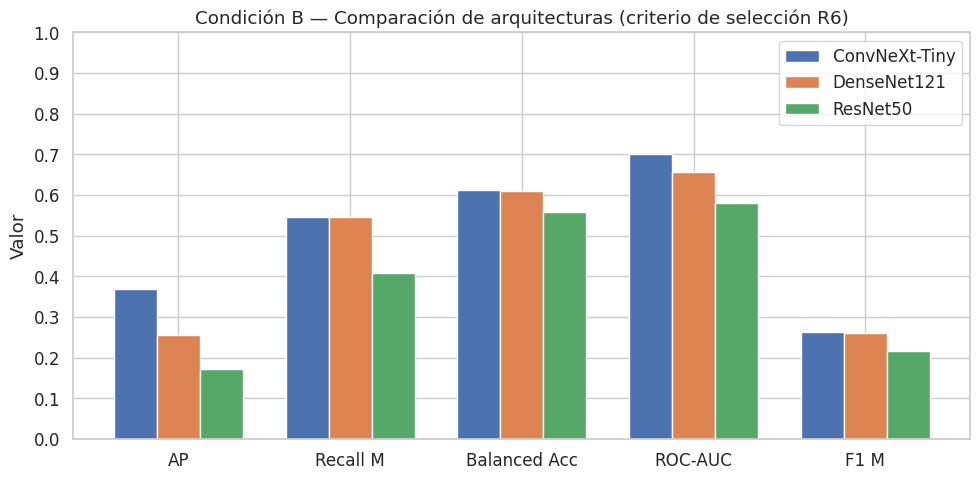

In [8]:
df_B = df[df["Condición"] == "B"].copy()
df_B_sorted = df_B.sort_values(
    by=["AP", "Recall M", "Balanced Acc"],
    ascending=False
).reset_index(drop=True)
df_B_sorted.index = df_B_sorted.index + 1
df_B_sorted.index.name = "Rank"

print("Ranking en Condición B (pipeline automatizado):")
display(df_B_sorted[["Arquitectura", "AP", "Recall M", "Balanced Acc",
                      "ROC-AUC", "F1 M", "Precision M", "Specificity"]])

fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = ["AP", "Recall M", "Balanced Acc", "ROC-AUC", "F1 M"]
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (_, row) in enumerate(df_B_sorted.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=row["Arquitectura"])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1)
ax.set_ylabel("Valor")
ax.set_title("Condición B — Comparación de arquitecturas (criterio de selección R6)")
ax.legend()
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
plt.tight_layout()
plt.show()

## 7. Matrices de confusión (validación, best checkpoint)

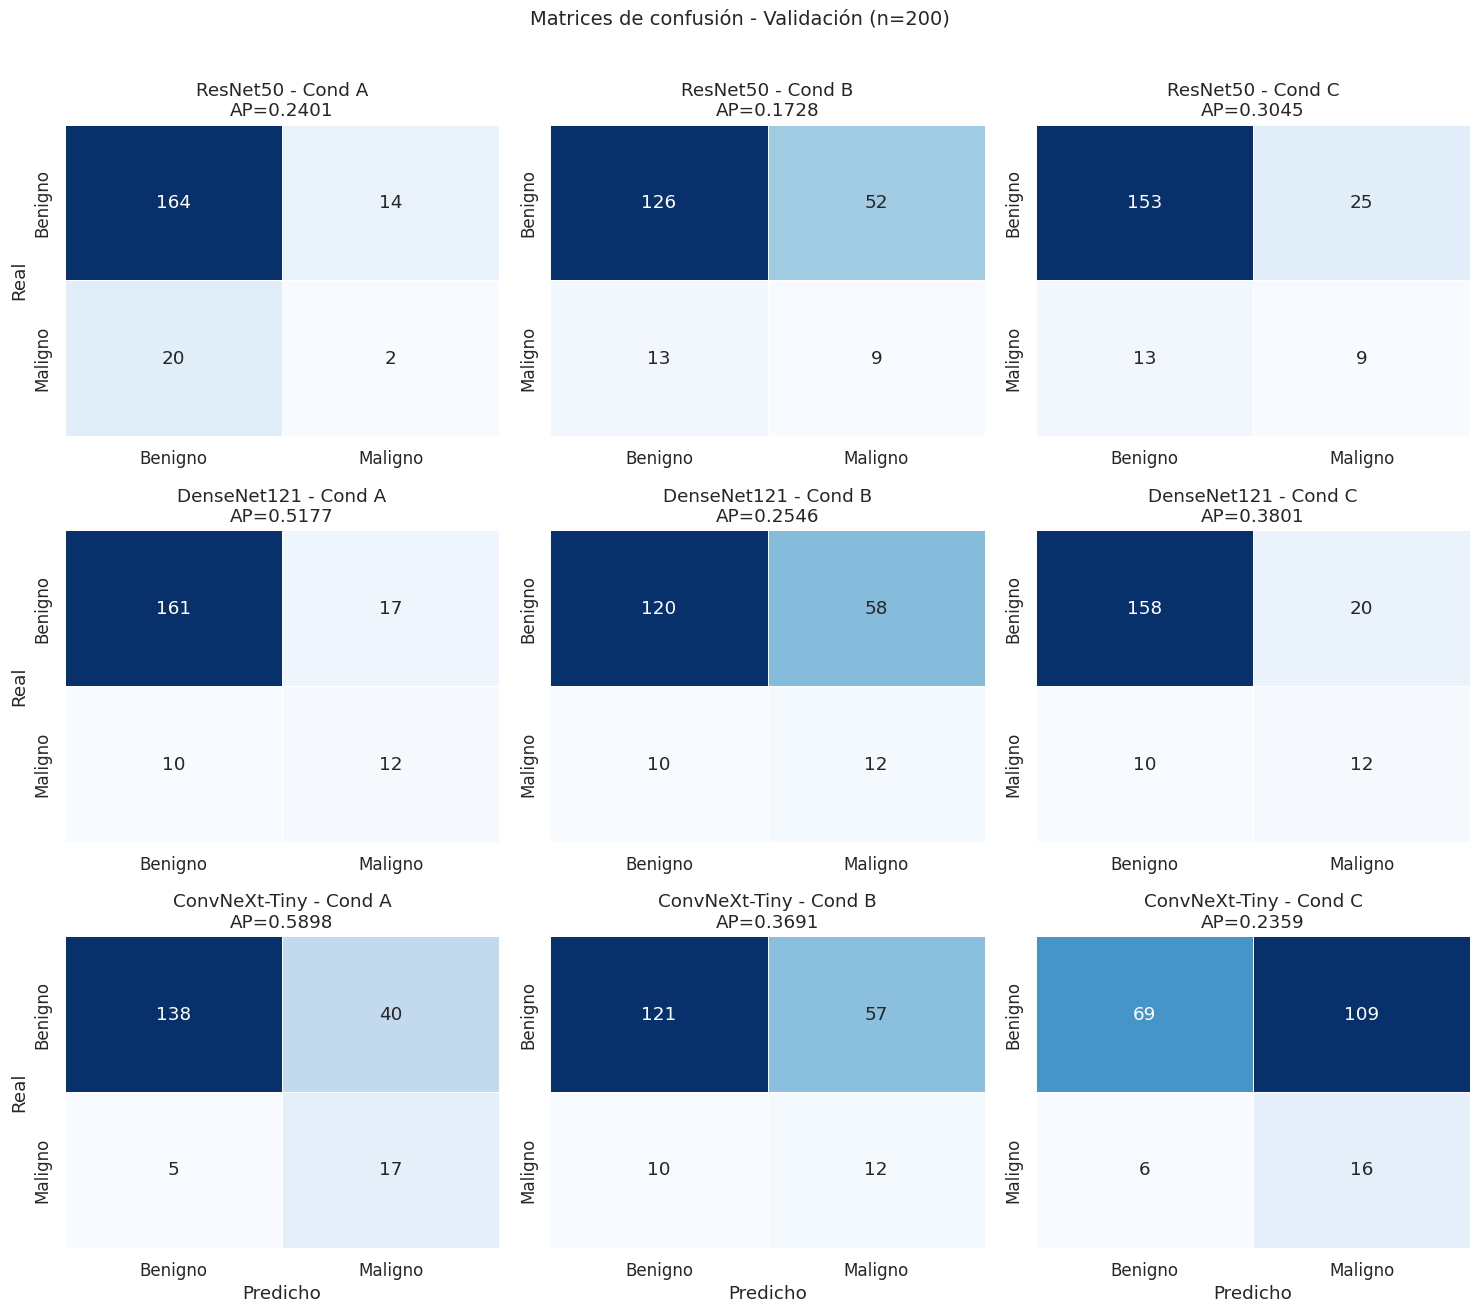

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
class_names = ["Benigno", "Maligno"]

for i, arch in enumerate(ARCHS):
    for j, cond in enumerate(CONDITIONS):
        ax = axes[i, j]
        row = df[(df["arch_key"] == arch) & (df["Condición"] == cond)].iloc[0]
        cm = np.array(row["CM"])

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=class_names, yticklabels=class_names,
                    cbar=False, linewidths=0.5)
        ax.set_title(f"{ARCH_LABELS[arch]} - Cond {cond}\nAP={row['AP']:.4f}")
        if j == 0:
            ax.set_ylabel("Real")
        if i == 2:
            ax.set_xlabel("Predicho")

fig.suptitle("Matrices de confusión - Validación (n=200)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Panorama descriptivo: AP por arquitectura × condición

Vista descriptiva de las 9 corridas. Este ranking global **no** es el criterio de selección de arquitectura (que se realiza exclusivamente en condición B, sección 6). Su función es mostrar cómo se distribuye el rendimiento entre condiciones.

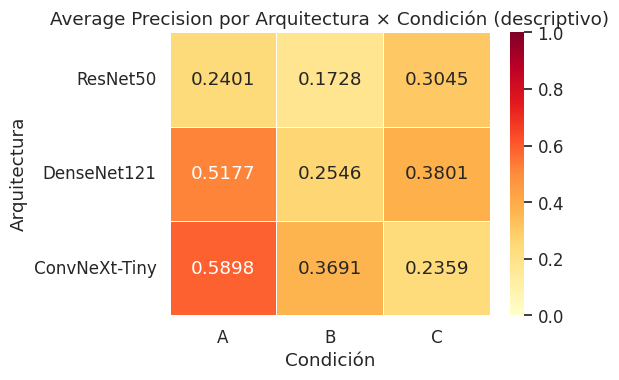

Ordenamiento descriptivo de las 9 corridas por AP:
(No constituye criterio de selección - ver sección 6)


,Arquitectura,Condición,AP,Recall M,Balanced Acc,ROC-AUC,F1 M,Epoch Best
#,,,,,,,,
1,ConvNeXt-Tiny,A,0.5898,0.7727,0.7740,0.8853,0.4304,8
2,DenseNet121,A,0.5177,0.5455,0.7250,0.8483,0.4706,3
3,DenseNet121,C,0.3801,0.5455,0.7165,0.7837,0.4444,2
4,ConvNeXt-Tiny,B,0.3691,0.5455,0.6126,0.6997,0.2637,4
5,ResNet50,C,0.3045,0.4091,0.6343,0.6402,0.3214,1
6,DenseNet121,B,0.2546,0.5455,0.6098,0.6570,0.2609,2
7,ResNet50,A,0.2401,0.0909,0.5061,0.7188,0.1053,2
8,ConvNeXt-Tiny,C,0.2359,0.7273,0.5575,0.6210,0.2177,1
9,ResNet50,B,0.1728,0.4091,0.5585,0.5804,0.2169,1


In [10]:
pivot_ap = df.pivot(index="Arquitectura", columns="Condición", values="AP")
pivot_ap = pivot_ap.reindex(
    index=[ARCH_LABELS[a] for a in ARCHS],
    columns=CONDITIONS
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot_ap, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title("Average Precision por Arquitectura × Condición (descriptivo)")
plt.tight_layout()
plt.show()

df_global = df.sort_values(
    by=["AP", "Recall M", "Balanced Acc"],
    ascending=False
).reset_index(drop=True)
df_global.index = df_global.index + 1
df_global.index.name = "#"

print("Ordenamiento descriptivo de las 9 corridas por AP:")
print("(No constituye criterio de selección - ver sección 6)")
df_global[["Arquitectura", "Condición", "AP", "Recall M", "Balanced Acc",
           "ROC-AUC", "F1 M", "Epoch Best"]]

## 9. Resumen final

### Secuencia metodológica
- **R5 (Comparación controlada):** Se entrenaron 9 corridas (3 arquitecturas × 3 condiciones) bajo protocolo idéntico (Secciones 1 - 5).
- **R6 (Selección de arquitectura):** Se comparan las 3 arquitecturas exclusivamente en condición B. La sección 6 presenta el ranking y la selección.

In [11]:
print("="*70)
print("SELECCIÓN R6 - CONDICIÓN B (pipeline automatizado)")
print("="*70)

df_B_final = df[df["Condición"] == "B"].sort_values(
    by=["AP", "Recall M", "Balanced Acc"], ascending=False
).reset_index(drop=True)

winner = df_B_final.iloc[0]
print(f"\nArquitectura seleccionada: {winner['Arquitectura']}")
print(f"  AP:             {winner['AP']:.4f}")
print(f"  Recall M:       {winner['Recall M']:.4f}")
print(f"  Balanced Acc:   {winner['Balanced Acc']:.4f}")
print(f"  ROC-AUC:        {winner['ROC-AUC']:.4f}")
print(f"  F1 M:           {winner['F1 M']:.4f}")
print(f"  Specificity:    {winner['Specificity']:.4f}")

print(f"\n{'='*70}")
print(f"CONTEXTO: {winner['Arquitectura']} en las 3 condiciones")
print(f"{'='*70}")

winner_arch = winner["arch_key"]
df_winner_all = df[df["arch_key"] == winner_arch].set_index("Condición")

for cond in CONDITIONS:
    row = df_winner_all.loc[cond]
    print(f"  Condición {cond}: AP={row['AP']:.4f}  Recall M={row['Recall M']:.4f}  Bal Acc={row['Balanced Acc']:.4f}")

gap_CB = df_winner_all.loc["C", "AP"] - df_winner_all.loc["B", "AP"]
gap_BA = df_winner_all.loc["B", "AP"] - df_winner_all.loc["A", "AP"]
print(f"\n  Δ AP (B-A): {gap_BA:+.4f}")
print(f"  Δ AP (C-B): {gap_CB:+.4f}")

print(f"\n{'='*70}")
print("MOTIVACIÓN PARA R7")
print(f"{'='*70}")
print(f"  Mejor epoch en B: {winner['Epoch Best']} de {winner['Epochs Run']} ejecutadas")
print(f"  Todas las corridas terminaron por early stopping.")
print(f"  El sobreajuste temprano motiva explorar técnicas de regularización")
print(f"  y scheduling en R7, manteniendo la arquitectura {winner['Arquitectura']}.")
print(f"\n  Secuencia: R5 -> R6 (selección: {winner['Arquitectura']}) -> R7 (optimización)")

SELECCIÓN R6 - CONDICIÓN B (pipeline automatizado)

Arquitectura seleccionada: ConvNeXt-Tiny
  AP:             0.3691
  Recall M:       0.5455
  Balanced Acc:   0.6126
  ROC-AUC:        0.6997
  F1 M:           0.2637
  Specificity:    0.6798

CONTEXTO: ConvNeXt-Tiny en las 3 condiciones
  Condición A: AP=0.5898  Recall M=0.7727  Bal Acc=0.7740
  Condición B: AP=0.3691  Recall M=0.5455  Bal Acc=0.6126
  Condición C: AP=0.2359  Recall M=0.7273  Bal Acc=0.5575

  Δ AP (B-A): -0.2207
  Δ AP (C-B): -0.1331

MOTIVACIÓN PARA R7
  Mejor epoch en B: 4 de 9 ejecutadas
  Todas las corridas terminaron por early stopping.
  El sobreajuste temprano motiva explorar técnicas de regularización
  y scheduling en R7, manteniendo la arquitectura ConvNeXt-Tiny.

  Secuencia: R5 -> R6 (selección: ConvNeXt-Tiny) -> R7 (optimización)


### Notas metodológicas

- **AP** se usa como métrica principal porque es robusta ante el desbalance de clases (~8:1 benigno:maligno).
- La **Condición B** es el escenario operativo real: la U-Net predice la máscara, se extrae el ROI y la CNN clasifica. Es la única condición que determina la selección de arquitectura en R6.
- La **Condición C** es una condición de referencia (oráculo): usa ROIs derivadas de la segmentación manual, lo que no es reproducible en el pipeline automático. La diferencia C−B refleja el cambio de desempeño al sustituir la ROI predicha por una ROI basada en GT, sin atribución causal directa a errores de segmentación.
- La **Condición A** es el baseline sin segmentación previa.
- Las corridas formales de R5/R6 no utilizan el conjunto de test para la selección ni la comparación. Existió una inspección preliminar previa del test que se documentará como limitación metodológica.
- El protocolo de entrenamiento incluye aumentación de datos, weight decay y early stopping de forma común a todas las corridas. No se añadieron scheduler ni optimizaciones específicas por arquitectura, garantizando comparabilidad estricta entre condiciones.
- Las corridas de R5 no se modifican ni se repiten. El sobreajuste observado se aborda en R7 mediante optimización del modelo seleccionado.